## Let's simulate OptimAc on the data collected by the survey

### Data import and formating into participant lists

In [8]:
import pandas as pan
from participant_real import Participant

dfs = [f0,f1]  = [pan.read_csv("../data/experimental2/filtered/f0.csv"), pan.read_csv("../data/experimental2/filtered/f1.csv")]
f0.groupby("action_name")["motivation"].sum()

action_name
as_usual    121
monthly      89
weekly     -106
Name: motivation, dtype: int64

In [9]:
action_names = [["as_usual","monthly","weekly"],["monthly","notatall","weekly"]]
participants = [[],[]]

extract_data = lambda df :list(df.groupby("n")["motivation"].apply(list).items())
# data is extracted from the dataframe as a list of (id, motivations list)
id_and_motivation_lists = [extract_data(f0), extract_data(f1)]

for scenario in range (2):
    for (id_number,motivationlist) in id_and_motivation_lists[scenario]:
        motiv_dict = {k:v for (k,v) in zip(action_names[scenario][::-1],motivationlist)}
        participants[scenario].append(Participant(id_number,motiv_dict).to_dict())

part_dfs = [pan.DataFrame(participants[scenario]) for scenario in range(2)]

part_dfs[0]

,id,motivations,measures
0,1,"{'weekly': -2, 'monthly': 2, 'as_usual': 2}",0
1,2,"{'weekly': -3, 'monthly': 3, 'as_usual': 2}",0
2,5,"{'weekly': -3, 'monthly': -3, 'as_usual': 3}",0
3,7,"{'weekly': -1, 'monthly': 1, 'as_usual': 2}",0
4,8,"{'weekly': -1, 'monthly': 1, 'as_usual': 1}",0
...,...,...,...
68,123,"{'weekly': -2, 'monthly': 1, 'as_usual': 2}",0
69,124,"{'weekly': -3, 'monthly': 2, 'as_usual': 2}",0
70,125,"{'weekly': -2, 'monthly': 2, 'as_usual': 2}",0
71,126,"{'weekly': -3, 'monthly': -1, 'as_usual': 2}",0


## Simulation

We use target distribution $d_i = 1/3$ with $pa_i = 10$

In [10]:
from Optimac import allocate_actions_to_participants

d = [1/2,1/4,1/4]
d = [1/3,1/3,1/3]
pa = 10

simulate_scenario = lambda scenario : allocate_actions_to_participants(part_dfs[scenario],{ac : {"target": d[idx], "current":0,"minimum" :pa}for idx,ac in enumerate(action_names[scenario])})

#results = [simulate_scenario(i) for i in range(2)]



## Results analysis

### Dropouts
Now let's compare dropouts with other methods, first we have to simulate those other methods on the participants. Note that the random method is treated aside due to its randomness.

In [11]:
import matplotlib.pyplot as plt 
import random as rd
from time import time
import numpy as np


feedback_map = {"Oui":1, "Oui, mais pas sûr":0.5,"Non":0}
methods = ["optimac","random","roundrobin","highestrank"]
det_methods = ["optimac","roundrobin","highestrank"]

def random_assignment(participant,scenario):
    selected = action_names[scenario][rd.randrange(3)]
    return (participant["id"],selected,participant["motivations"][selected])

def roundrobin_assignment(n,participant,scenario):
    selected = action_names[scenario][n%3]
    return (participant["id"],selected,participant["motivations"][selected])

def highestrank_assignment(participant,scenario):
    max_motiv = -float("inf")
    highest_ranked_action = ""
    motivs = list(participant["motivations"].items() )
    rd.shuffle(motivs)
    for (k,v) in motivs:
        if v > max_motiv:
            highest_ranked_action = k
            max_motiv = v
    return(participant["id"],highest_ranked_action,participant["motivations"][highest_ranked_action])


def compute_stats(scenario):
    #This function computes the number of participant per action before and after the dropouts simulation
    assignments = {}

    assignments["roundrobin"] = pan.DataFrame([roundrobin_assignment(idx,p,scenario) for idx,p in enumerate(participants[scenario])],columns=["id","action","motivation"])
    assignments["highestrank"] = pan.DataFrame([highestrank_assignment(p,scenario) for p in participants[scenario]],columns=["id","action","motivation"])
    assignments["optimac"] = pan.DataFrame(simulate_scenario(scenario),columns=["id","action","motivation"])


    stats_before = {m:(assignments[m].groupby("action")["action"].count().values,[0,0,0]) for m in det_methods}
    dev_before = {m:(assignments[m].groupby("action")["action"].count().div(len(assignments[m])).sub(d).abs().values,[0,0,0]) for m in det_methods}
    rd_before = []
    rd_before_dev =[]
    feedbacks = {}
    remaining_parts = {m:[] for m in methods}
    deviations= {m:[] for m in methods}
    stats_after = {m:[] for m in methods}
    dev_after = {m:[] for m in methods}
    for m in det_methods:
        feedbacks[m] = dfs[scenario].merge(assignments[m],left_on=["n", "action_name"], right_on=["id", "action"], how="inner")[["id","action","feedback"]]
        feedbacks[m]["feedback"] = feedbacks[m]["feedback"].map(feedback_map) 
    for _ in range(50):
        #computing the random assignments
        rd_assignment = pan.DataFrame([random_assignment(p,scenario) for p in participants[scenario]],columns=["id","action","motivation"])
        rd_before.append(rd_assignment.groupby("action")["action"].count().values)
        rd_before_dev.append(rd_assignment.groupby("action")["action"].count().div(len(rd_assignment)).sub(d).abs().values)
        #print(rd_assignment.groupby("action")["action"].count().div(len(rd_assignment)).sub(d).abs())
        feedbacks["random"] = dfs[scenario].merge(rd_assignment,left_on=["n", "action_name"], right_on=["id", "action"], how="inner")[["id","action","feedback"]]
        feedbacks["random"]["feedback"] = feedbacks["random"]["feedback"].map(feedback_map)
        assignments["random"] = rd_assignment

        random_dropouts = [rd.random() for _ in range(len(feedbacks["random"]))]
        for m in methods : 
            remaining_parts[m].append(feedbacks[m][feedbacks[m]["feedback"]>random_dropouts].groupby("action")["action"].count().values)
            # print(feedbacks[m][feedbacks[m]["feedback"]>random_dropouts].groupby("action")["action"].count().values)
            deviations[m].append(feedbacks[m][feedbacks[m]["feedback"]>random_dropouts].groupby("action")["action"].count().div(len(assignments[m])).sub(d).abs().values)
    for m in methods:
        array = np.array(remaining_parts[m])
        stats_after[m] =[array.mean(axis = 0),array.std(axis=0)]
        array = np.array(deviations[m])
        dev_after[m] = [array.mean(axis = 0),array.std(axis=0)]

    array = np.array(rd_before)
    stats_before["random"] = [array.mean(axis =0),array.std(axis = 0)]
    array = np.array(rd_before_dev)
    dev_before["random"] = [array.mean(axis =0),array.std(axis = 0)]
    return stats_before,stats_after,dev_before,dev_after




Now let's analyze the results from these simulations.

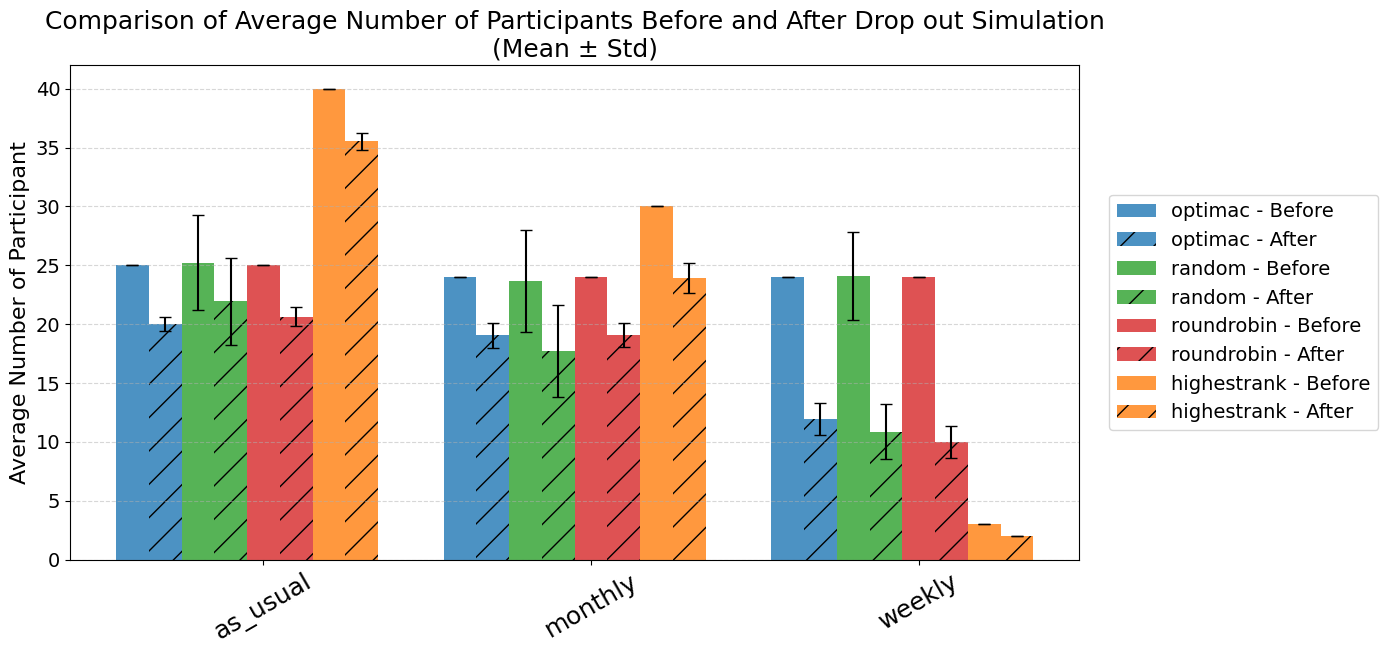

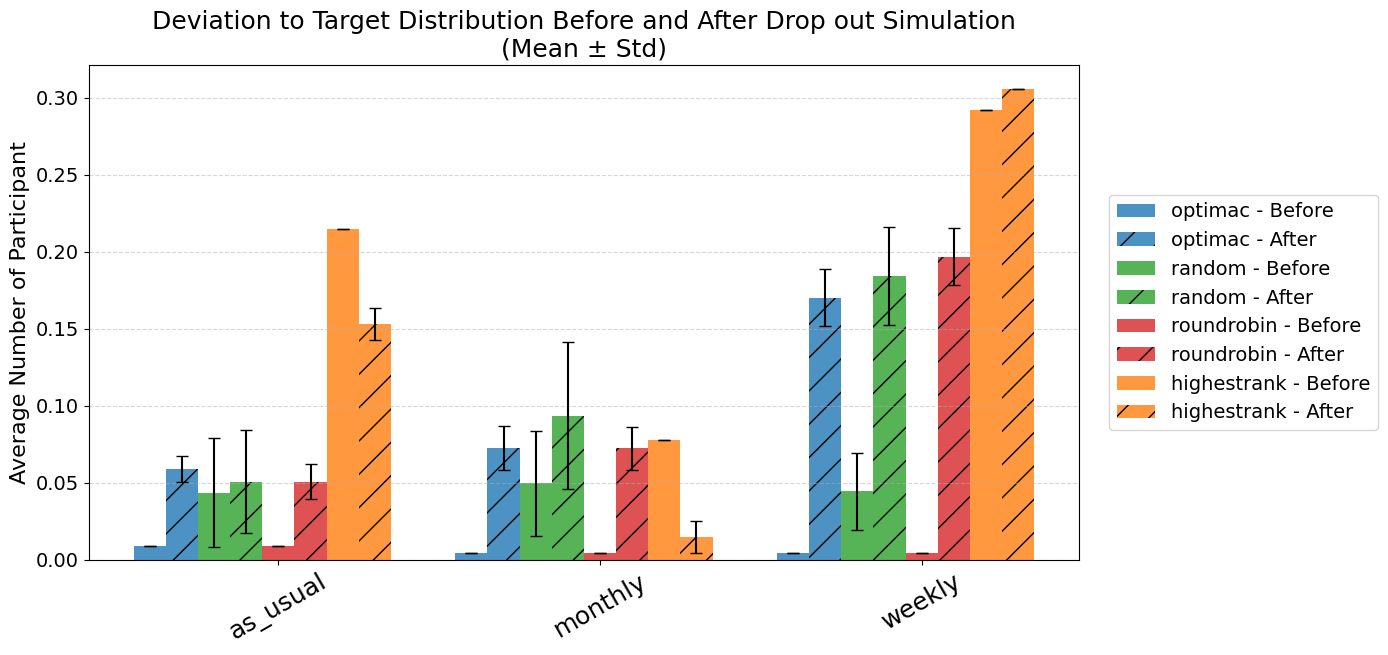

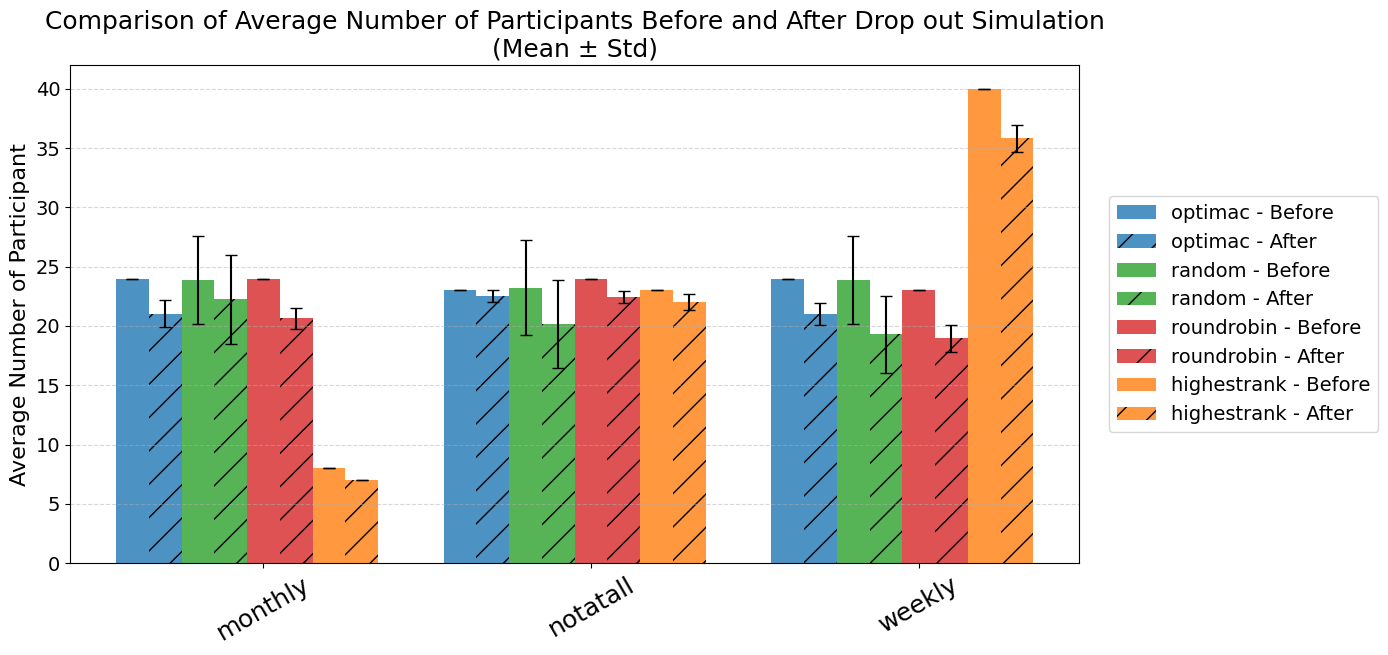

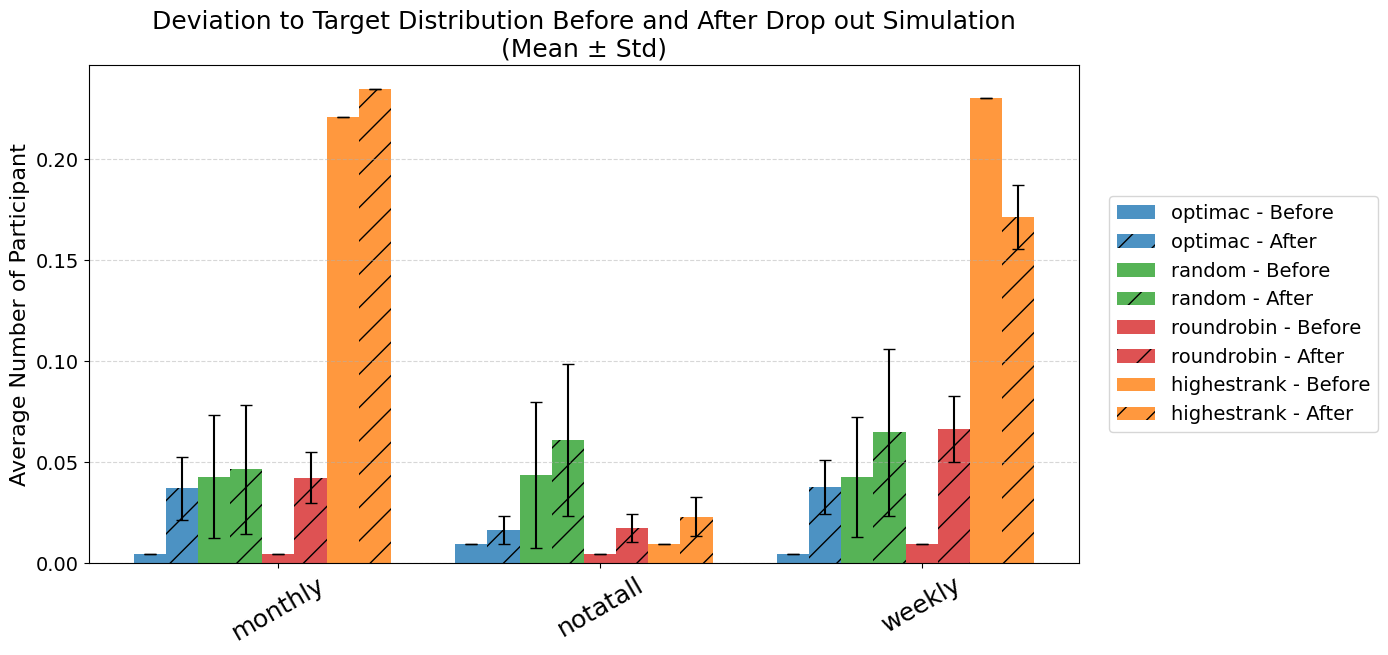

In [12]:
methods = ["optimac","random","roundrobin","highestrank"]
method_colors = {
    "optimac": "#1f77b4",
    "highestrank": "#ff7f0e",
    "random": "#2ca02c",
    "roundrobin": "#d62728"
}
hatch_before = ""
hatch_after = "/"

# --- Plotting ---
def plotting_ba_bars(stats_before,stats_after,title):
    #Function generating before/after dropout simulation bar plots
    categories = action_names[scenario]
    x = np.arange(len(categories))
    total_width = 0.8
    n_methods = len(methods)
    bar_width = total_width / (2 * n_methods)  # Each method has 2 bars: before & after

    fig, ax = plt.subplots(figsize=(14, 7))

    for idx, method in enumerate(methods):
        mean_before, std_before = stats_before[method]
        mean_after, std_after = stats_after[method]

        offsets = x + (idx - n_methods / 2) * 2 * bar_width + bar_width / 2
        color = method_colors[method]

        # Before bars
        ax.bar(offsets - bar_width / 2, mean_before, bar_width, yerr=std_before,
            label=f'{method} - Before', capsize=4, color=color, hatch=hatch_before, alpha=0.8)

        # After bars
        ax.bar(offsets + bar_width / 2, mean_after, bar_width, yerr=std_after,
            label=f'{method} - After', capsize=4, color=color, hatch=hatch_after, alpha=0.8)

    # --- Formatting with larger fonts ---
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, fontsize=18)
    ax.set_ylabel("Average Number of Participant", fontsize=16)
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Legend with bigger font
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=14)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

for scenario in range(2):
    stats_before,stats_after,dev_before,dev_after = compute_stats(scenario)
    plotting_ba_bars(stats_before, stats_after,"Comparison of Average Number of Participants Before and After Drop out Simulation\n(Mean ± Std)")
    plotting_ba_bars(dev_before,dev_after,"Deviation to Target Distribution Before and After Drop out Simulation\n(Mean ± Std)")
    

### Deviation to target distribution


In [13]:
def compute_dev(stats_before,stats_after,scenario):
    s = len(dfs[scenario])
    deviations = {m:[abs(x/s - d) for x,_ in stats_before[m]] for m in stats_before}
    dev_err = {m:np.std(deviations[m]) for m in deviations}

    
